In [1]:
import pickle
import os

from pyboolnet.interaction_graphs import primes2igraph

In [2]:
DIR1 = "../case_study/T_cell/N10/results/20260617/"
DIR2 = "../case_study/T_cell/N10/results/20260621_1/"
DIR3 = "../case_study/T_cell/N10/results/20260621_2/"
DIRS = [DIR1, DIR2, DIR3]

In [3]:
graphs = []
for DIR in DIRS:
    directory = os.listdir(DIR)
    print(f"{DIR}: {len(directory)} files")

    for filename in directory:
        if filename.endswith(".pkl"):
            primes = pickle.load(open(os.path.join(DIR, filename), "rb"))
            
            graph = primes2igraph(primes)
            graphs.append(graph)

print(len(graphs))

../case_study/T_cell/N10/results/20260617/: 156 files
../case_study/T_cell/N10/results/20260621_1/: 138 files
../case_study/T_cell/N10/results/20260621_2/: 134 files
214


In [4]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 1. CORE UTIL
# =========================================================

def normalize_sign(s):
    if s in (1, "positive", "+", "pos"):
        return 1
    if s in (-1, "negative", "-", "neg"):
        return -1
    return 1  # default fallback (safer for messy graphs)


def build_edge_matrix(graphs, signed=False):
    """
    X[k, e] = 1 if edge e exists in graph k.
    If signed=True, ignores sign for presence (sign handled elsewhere).
    """
    edges = sorted({(u, v) for G in graphs for u, v in G.edges()})
    index = {e: i for i, e in enumerate(edges)}

    X = np.zeros((len(graphs), len(edges)), dtype=float)

    for k, G in enumerate(graphs):
        for u, v in G.edges():
            X[k, index[(u, v)]] = 1.0

    return X, edges, index


# =========================================================
# 2. EDGE STATISTICS (probability + sign + weight)
# =========================================================

def compute_edge_statistics(graphs):
    """
    Returns:
        edge_prob[e]
        edge_sign[e]
        edge_weight[e] = p_e * sign
        edges (list)
    """
    edge_count = {}
    sign_sum = {}

    for G in graphs:
        for u, v, data in G.edges(data=True):
            e = (u, v)

            edge_count[e] = edge_count.get(e, 0) + 1
            sign_sum[e] = sign_sum.get(e, 0) + normalize_sign(data.get("sign", 1))

    n = len(graphs)

    edge_prob = {}
    edge_sign = {}
    edge_weight = {}

    for e in edge_count:
        p = edge_count[e] / n
        s = np.sign(sign_sum[e] / edge_count[e])

        edge_prob[e] = p
        edge_sign[e] = s
        edge_weight[e] = p * s

    return edge_prob, edge_sign, edge_weight, list(edge_count.keys())


# =========================================================
# 3. CO-VARIATION (cov + lift)
# =========================================================

def compute_cov_lift(graphs):
    X, edges, index = build_edge_matrix(graphs)
    n, m = X.shape

    p = X.mean(axis=0)

    cov = np.zeros((m, m))
    lift = np.zeros((m, m))

    eps = 1e-12

    for i in range(m):
        for j in range(m):
            pij = np.mean(X[:, i] * X[:, j])

            cov[i, j] = pij - p[i] * p[j]
            lift[i, j] = pij / (p[i] * p[j] + eps)

    return {
        "edges": edges,
        "p": p,
        "cov": cov,
        "lift": lift,
        "index": index
    }


# =========================================================
# 4. CONSENSUS GRAPH
# =========================================================

def build_consensus_graph(edge_prob, edge_sign, threshold=0.8):
    Gc = nx.DiGraph()

    for (u, v), p in edge_prob.items():
        if p >= threshold:
            Gc.add_edge(u, v, weight=p, sign=edge_sign[(u, v)])

    return Gc


# =========================================================
# 5. HEATMAP VISUALIZATION
# =========================================================

def plot_edge_matrix(matrix, p, title, log_scale=False):
    order = np.argsort(-p)  # sort by probability (descending)

    M = matrix[np.ix_(order, order)]

    if log_scale:
        M = np.log(M + 1e-12)

    plt.figure(figsize=(10, 8))
    plt.imshow(M, cmap="coolwarm", aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("Edges (sorted by frequency)")
    plt.ylabel("Edges (sorted by frequency)")
    plt.tight_layout()
    plt.show()


# =========================================================
# 6. HIGH-LEVEL WRAPPERS
# =========================================================

def analyze_graph_ensemble(graphs):
    """
    One-shot computation of everything useful.
    """
    edge_prob, edge_sign, edge_weight, _ = compute_edge_statistics(graphs)
    stats = compute_cov_lift(graphs)

    return {
        "edge_prob": edge_prob,
        "edge_sign": edge_sign,
        "edge_weight": edge_weight,
        "cov": stats["cov"],
        "lift": stats["lift"],
        "edges": stats["edges"],
        "p_vector": stats["p"]
    }


def plot_covariance(graphs):
    stats = compute_cov_lift(graphs)
    plot_edge_matrix(stats["cov"], stats["p"], "Edge Covariance (ordered by probability)")


def plot_lift(graphs):
    stats = compute_cov_lift(graphs)
    plot_edge_matrix(stats["lift"], stats["p"], "Log Edge Lift (ordered by probability)", log_scale=True)

In [5]:
result = analyze_graph_ensemble(graphs)

In [6]:
print(result)

{'edge_prob': {('APC', 'APC'): 1.0, ('APC', 'CD28'): 1.0, ('APC', 'TCR'): 1.0, ('CD28', 'NFAT'): 1.0, ('FOXP3', 'FOXP3'): 0.102803738317757, ('FOXP3', 'IFNG'): 1.0, ('FOXP3', 'IL17'): 0.46261682242990654, ('FOXP3', 'IL2RA'): 1.0, ('FOXP3', 'IL4'): 1.0, ('FOXP3', 'NFKB'): 1.0, ('FOXP3', 'TGFB'): 0.6822429906542056, ('GATA3', 'GATA3'): 1.0, ('GATA3', 'IL4'): 1.0, ('GATA3', 'TBET'): 1.0, ('IFNBR', 'STAT1'): 1.0, ('IFNB_e', 'IFNBR'): 1.0, ('IFNB_e', 'IFNB_e'): 1.0, ('IFNG', 'IFNGR'): 1.0, ('IFNGR', 'STAT1'): 1.0, ('IFNG_e', 'IFNGR'): 1.0, ('IFNG_e', 'IFNG_e'): 1.0, ('IKB', 'NFKB'): 1.0, ('IL10', 'IL10R'): 1.0, ('IL10R', 'STAT3'): 1.0, ('IL10_e', 'IL10R'): 1.0, ('IL10_e', 'IL10_e'): 1.0, ('IL12R', 'STAT4'): 0.6822429906542056, ('IL12RB2', 'IL12R'): 1.0, ('IL12_e', 'IL12R'): 1.0, ('IL12_e', 'IL12_e'): 1.0, ('IL15_e', 'IL15R'): 1.0, ('IL15_e', 'IL15_e'): 1.0, ('IL2', 'IL2R'): 1.0, ('IL21', 'IL21R'): 1.0, ('IL21_e', 'IL21R'): 1.0, ('IL21_e', 'IL21_e'): 1.0, ('IL23', 'IL23R'): 1.0, ('IL23R', 'S

In [7]:
print(result["edge_prob"])

always_exist = []
always_nonexist = []
for edge, edge_prob in result["edge_prob"].items():
    if edge_prob == 1.0:
        always_exist.append(edge)
    elif edge_prob == 0.0:
        always_nonexist.append(edge)
print("Always exist:", always_exist, len(always_exist))
print("Always nonexist:", always_nonexist, len(always_nonexist))

{('APC', 'APC'): 1.0, ('APC', 'CD28'): 1.0, ('APC', 'TCR'): 1.0, ('CD28', 'NFAT'): 1.0, ('FOXP3', 'FOXP3'): 0.102803738317757, ('FOXP3', 'IFNG'): 1.0, ('FOXP3', 'IL17'): 0.46261682242990654, ('FOXP3', 'IL2RA'): 1.0, ('FOXP3', 'IL4'): 1.0, ('FOXP3', 'NFKB'): 1.0, ('FOXP3', 'TGFB'): 0.6822429906542056, ('GATA3', 'GATA3'): 1.0, ('GATA3', 'IL4'): 1.0, ('GATA3', 'TBET'): 1.0, ('IFNBR', 'STAT1'): 1.0, ('IFNB_e', 'IFNBR'): 1.0, ('IFNB_e', 'IFNB_e'): 1.0, ('IFNG', 'IFNGR'): 1.0, ('IFNGR', 'STAT1'): 1.0, ('IFNG_e', 'IFNGR'): 1.0, ('IFNG_e', 'IFNG_e'): 1.0, ('IKB', 'NFKB'): 1.0, ('IL10', 'IL10R'): 1.0, ('IL10R', 'STAT3'): 1.0, ('IL10_e', 'IL10R'): 1.0, ('IL10_e', 'IL10_e'): 1.0, ('IL12R', 'STAT4'): 0.6822429906542056, ('IL12RB2', 'IL12R'): 1.0, ('IL12_e', 'IL12R'): 1.0, ('IL12_e', 'IL12_e'): 1.0, ('IL15_e', 'IL15R'): 1.0, ('IL15_e', 'IL15_e'): 1.0, ('IL2', 'IL2R'): 1.0, ('IL21', 'IL21R'): 1.0, ('IL21_e', 'IL21R'): 1.0, ('IL21_e', 'IL21_e'): 1.0, ('IL23', 'IL23R'): 1.0, ('IL23R', 'STAT3'): 1.0, (

In [8]:
constraints = {"fixed": [],
                "regulate": {
                    "CD28": ["APC"],
                    "FOXP3": ["NFAT", "RORGT", "SMAD3", "STAT5"],
                    "GATA3": ["STAT6"],
                    "IFNBR": ["IFNB_e"],
                    "IFNG": ["RUNX3", "TBET"],
                    "IFNGR": ["IFNG", "IFNG_e"],
                    "IKB": ["TCR"],
                    "IL10R": ["IL10", "IL10_e"],
                    "IL12R": ["IL12RB2", "IL12_e"],
                    "IL15R": ["IL15_e"],
                    "IL17": ["STAT3", "STAT5"],
                    "IL2": ["NFKB"],
                    "IL21": ["STAT3"],
                    "IL21R": ["IL21", "IL21_e"],
                    "IL23": ["STAT3"],
                    "IL23R": ["IL23", "IL23_e", "RORGT", "STAT3"],
                    "IL27R": ["IL27_e"],
                    "IL2R": ["IL2", "IL2_e"],
                    "IL2RA": ["FOXP3", "NFAT", "NFKB", "STAT5"],
                    "IL4": ["GATA3", "NFAT", "RUNX3", "TBET"],
                    "IL4R": ["IL4", "IL4_e"],
                    "IL6R": ["IL6_e"],
                    "NFAT": ["CD28", "TCR"],
                    "NFKB": ["FOXP3", "IKB"],
                    "RORGT": ["STAT3"],
                    "STAT1": ["IFNBR", "IFNGR", "IL27R"],
                    "STAT3": ["IL10R", "IL23R", "IL27R", "IL6R"],
                    "STAT5": ["IL2R"],
                    "TBET": ["STAT1", "TBET"],
                    "TGFBR": ["TGFB", "TGFB_e"]
                },
                "necessary": {
                    "IL17": ["RORGT"],
                    "IL2": ["NFAT"],
                    "IL2R_2": ["IL2R"],
                    "IL4R_2": ["IL4R"],
                    "STAT5_2": ["STAT5"],
                    "TCR": ["APC"]
                },
                "group": {},
                "possible_constant": []}

In [15]:
constraint_edges = []

for target in constraints["regulate"]:
    for reg in constraints["regulate"][target]:
        constraint_edges.append((reg, target))
for target in constraints["necessary"]:
    for reg in constraints["necessary"][target]:
        constraint_edges.append((reg, target))
print(len(constraint_edges))
print(constraint_edges)

65
[('APC', 'CD28'), ('NFAT', 'FOXP3'), ('RORGT', 'FOXP3'), ('SMAD3', 'FOXP3'), ('STAT5', 'FOXP3'), ('STAT6', 'GATA3'), ('IFNB_e', 'IFNBR'), ('RUNX3', 'IFNG'), ('TBET', 'IFNG'), ('IFNG', 'IFNGR'), ('IFNG_e', 'IFNGR'), ('TCR', 'IKB'), ('IL10', 'IL10R'), ('IL10_e', 'IL10R'), ('IL12RB2', 'IL12R'), ('IL12_e', 'IL12R'), ('IL15_e', 'IL15R'), ('STAT3', 'IL17'), ('STAT5', 'IL17'), ('NFKB', 'IL2'), ('STAT3', 'IL21'), ('IL21', 'IL21R'), ('IL21_e', 'IL21R'), ('STAT3', 'IL23'), ('IL23', 'IL23R'), ('IL23_e', 'IL23R'), ('RORGT', 'IL23R'), ('STAT3', 'IL23R'), ('IL27_e', 'IL27R'), ('IL2', 'IL2R'), ('IL2_e', 'IL2R'), ('FOXP3', 'IL2RA'), ('NFAT', 'IL2RA'), ('NFKB', 'IL2RA'), ('STAT5', 'IL2RA'), ('GATA3', 'IL4'), ('NFAT', 'IL4'), ('RUNX3', 'IL4'), ('TBET', 'IL4'), ('IL4', 'IL4R'), ('IL4_e', 'IL4R'), ('IL6_e', 'IL6R'), ('CD28', 'NFAT'), ('TCR', 'NFAT'), ('FOXP3', 'NFKB'), ('IKB', 'NFKB'), ('STAT3', 'RORGT'), ('IFNBR', 'STAT1'), ('IFNGR', 'STAT1'), ('IL27R', 'STAT1'), ('IL10R', 'STAT3'), ('IL23R', 'STAT3')

In [16]:
consensus_edges = []
for edge in always_exist:
    if edge not in constraint_edges:
        consensus_edges.append(edge)
print(len(consensus_edges))

weird_edges = []
for edge in constraint_edges:
    if edge not in always_exist:
        weird_edges.append(edge)
print(weird_edges)

print(consensus_edges)

26
[]
[('APC', 'APC'), ('FOXP3', 'IFNG'), ('FOXP3', 'IL4'), ('GATA3', 'GATA3'), ('GATA3', 'TBET'), ('IFNB_e', 'IFNB_e'), ('IFNG_e', 'IFNG_e'), ('IL10_e', 'IL10_e'), ('IL12_e', 'IL12_e'), ('IL15_e', 'IL15_e'), ('IL21_e', 'IL21_e'), ('IL23_e', 'IL23_e'), ('IL27_e', 'IL27_e'), ('IL2_e', 'IL2_e'), ('IL4R', 'STAT6'), ('IL4_e', 'IL4_e'), ('IL6_e', 'IL6_e'), ('IRF1', 'IL12RB1_2'), ('IRF1', 'IL4'), ('STAT1', 'IRF1'), ('STAT3', 'IFNG'), ('STAT6', 'IL12RB2'), ('TBET', 'RUNX3'), ('TGFBR', 'SMAD3'), ('TGFB_e', 'TGFB_e'), ('proliferation', 'IFNG')]


In [11]:
edge_prob, edge_sign, _, _ = compute_edge_statistics(graphs)
Gc = build_consensus_graph(edge_prob, edge_sign, threshold=1.0)

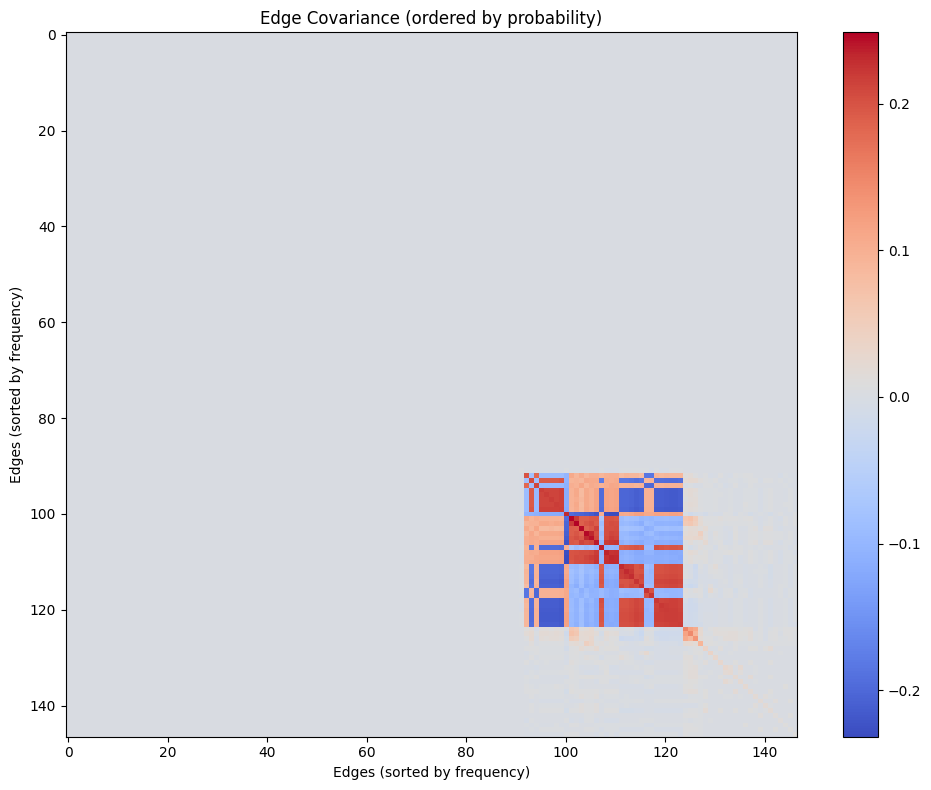

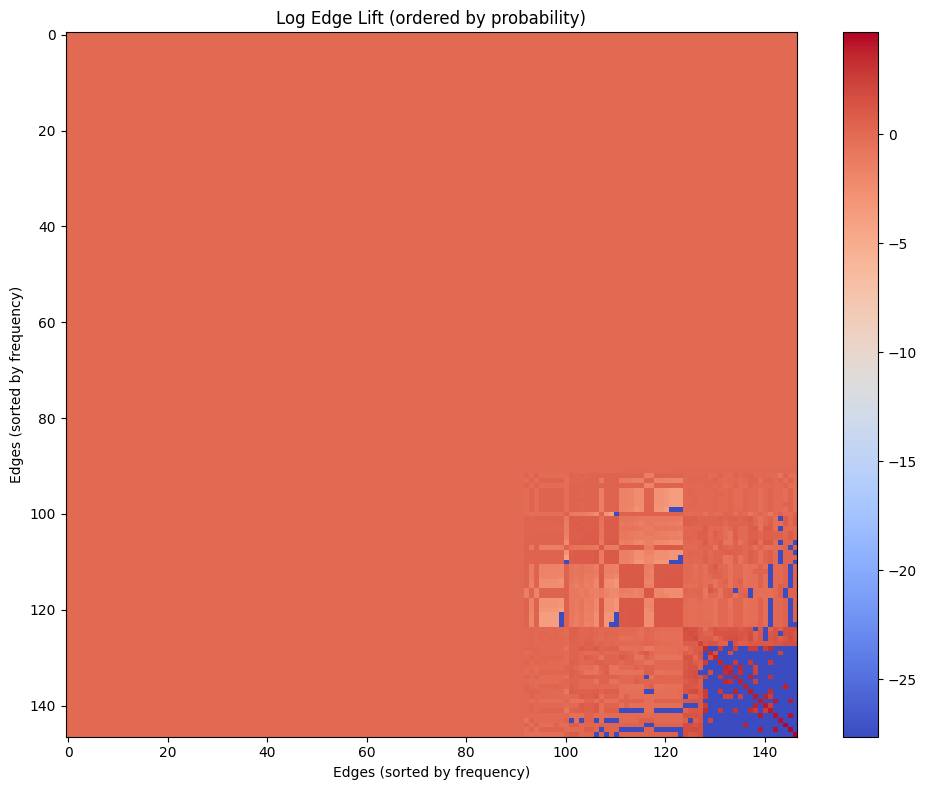

In [12]:
plot_covariance(graphs)
plot_lift(graphs)

In [13]:
import json
import numpy as np
import networkx as nx


def _sanitize_attrs(attrs: dict):
    """Convert GraphML-incompatible attribute types to JSON strings."""
    for k, v in list(attrs.items()):

        if isinstance(v, np.ndarray):
            v = v.tolist()

        elif isinstance(v, set):
            v = sorted(list(v))  # deterministic + GraphML-safe

        elif isinstance(v, (list, tuple)):
            v = list(v)

        elif isinstance(v, dict):
            v = v

        # recursively ensure everything becomes JSON-serializable scalar or string
        if isinstance(v, (list, dict)):
            attrs[k] = json.dumps(v)
        else:
            attrs[k] = v


def export_graphml(G: nx.DiGraph, path: str):
    G = G.copy()

    _sanitize_attrs(G.graph)

    for node, attrs in G.nodes(data=True):
        attrs.setdefault("label", str(node))
        _sanitize_attrs(attrs)

    for u, v, attrs in G.edges(data=True):
        attrs.setdefault("label", f"{u}->{v}")
        _sanitize_attrs(attrs)

    nx.write_graphml(G, path)

In [14]:
export_graphml(Gc, "consensus.graphml")